<a href="https://colab.research.google.com/github/TewodrosAdimas/A2SV/blob/main/Signal%20and%20Imaging%20Acquisition%20and%20Modelling%20in%20Healthcare/G5_EGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tasks
1- Creare simple code that uploads and plots the signal to see
499 Rows - Spectrum  

plot the first row all the observation


In [1]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Healthcare")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [ ]:
df = pd.read_excel('EEG-data.xlsx')

In [ ]:
# convert the dataset to Dataframe
pdf = pd.DataFrame(df)

In [ ]:
egg_list = df.to_numpy()

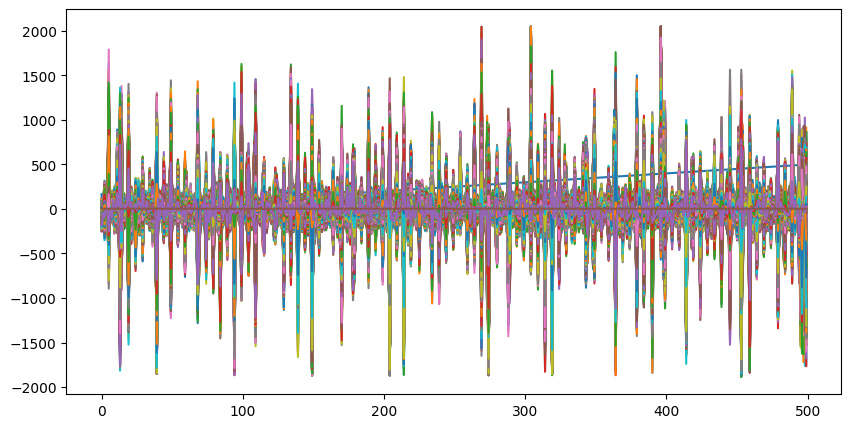

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(egg_list)
plt.show()

In [ ]:
pdf.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2
5,5,142,262,382,451,452,435,544,562,462,...,164,-2,-118,-223,-304,-350,-339,-299,-253,1
6,6,-64,-72,-52,-24,4,21,18,-16,-53,...,-90,-85,-66,-42,-26,-10,-1,-12,-16,5
7,7,-55,-48,-48,-38,-23,0,11,22,21,...,51,61,64,42,-1,-53,-79,-93,-95,4
8,8,18,14,13,9,-6,-20,-31,-27,-10,...,-17,-3,9,25,49,63,82,96,102,4
9,9,50,48,45,41,47,51,53,40,37,...,-16,-30,-47,-63,-63,-50,-39,-25,-19,3


### First 5 classes

In [ ]:
# egg_list[:5]

### Plot the first 2nd Class

Text(0, 0.5, 'Amplitude')

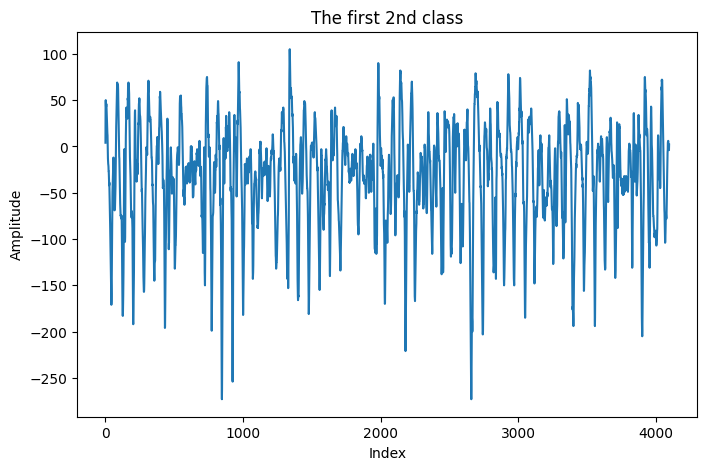

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(egg_list[4])
plt.title("The first 2nd class")
plt.xlabel("Index")
plt.ylabel("Amplitude")


### Find all the subject of level 2, 3 in the dataset  
### get insidght only the passient level 2 vs 3
### Readeing atutomatically classified without level to inform the parrent which level the
### Find the training and testing dataset
### Find the outlyier
### Characterized the dataset
### Training the model
### ===> 26th of the March both random forrest &

In [ ]:
# Find all the subject of level 2, 3 in the dataset
c2 =[]
c3 =[]
# y2 = []
# y3 = []
for row in egg_list:
  if(row[-1] == 2):
    c2.append(row[:-1])
  if(row[-1] == 3):
    c3.append(row[:-1])


In [ ]:
# Superate the dataset for training(80%) and test dataset(20%) and elemenate the unnamed atributes which is the first one
c2 = np.array(c2)
c3 = np.array(c3)
train_c2 = c2[:80, 1:]
train_c3 = c3[:80, 1:]
test_c2 = c2[-20:, 1:]
test_c3 = c3[-20:, 1:]

In [ ]:
# The mean value of the training dataset for class 2
c2_mean = np.mean(train_c2, axis=0)
c2_mean[10]

np.float64(0.6625)

# Normalization using z-transformation

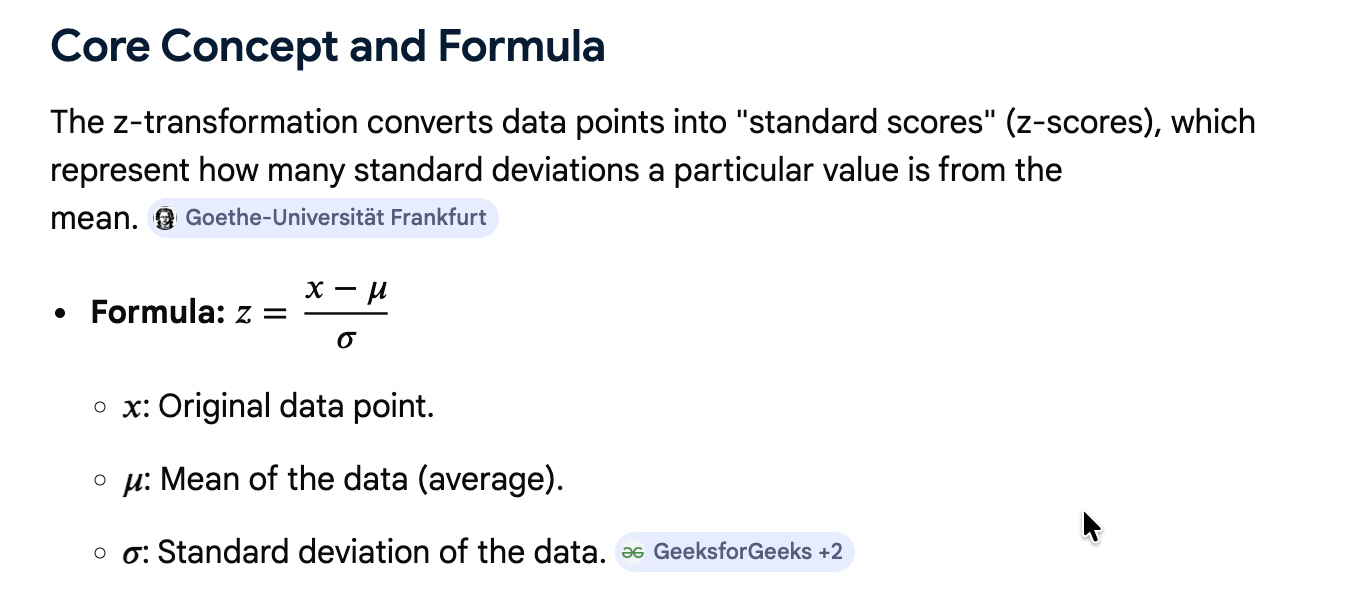

In [ ]:
# Normalize with z-transform
def z_tf(x, mean, sigma):
  return ((x-mean)/sigma)



## Task 2

1. **Normalize training & testing signals to the range [0, 1] and plot them.**

2. **Compute the mean and standard deviation of the normalized data.**

3. **Plot the mean of the normalized dataset.**

4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them

5. **Compute the distance of each signal from the mean in terms of standard deviation.**

6. **Classify a signal as an outlier if its distance is greater than a chosen threshold.** The threshold can be set to 1 or any other value depending on the analysis.


### 1. Normalize training & testing signals of class 2 & 3 and plot them.

In [ ]:
# 1. normalize the traingin & testing class 2
c2_training_norm = (train_c2 - np.mean(train_c2))/np.std(train_c2)
c2_testing_norm = (test_c2 - np.mean(test_c2))/np.std(test_c2)

# 2. normalize the traingin & testing class 3
c3_training_norm = (train_c3 - np.mean(train_c3))/np.std(train_c3)
c3_testing_norm = (test_c3 - np.mean(test_c3))/np.std(test_c3)

**Plot the normalized dataset**

<Figure size 1800x1000 with 0 Axes>

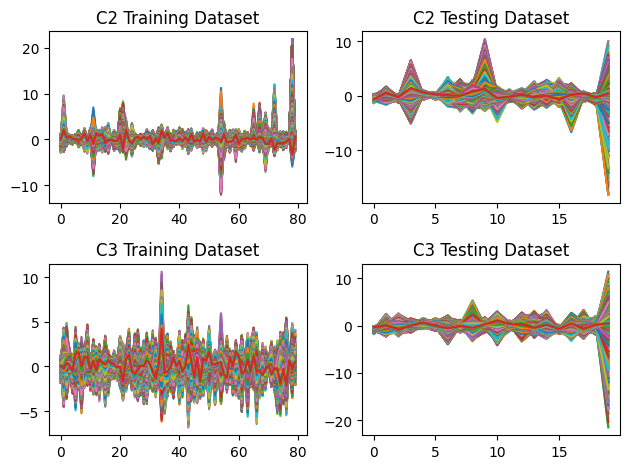

In [ ]:
# 1. Plot
plt.figure(figsize=(18, 10))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()
axes[0].plot(c2_training_norm , label="C2 Training Dataset")
axes[0].set_title("C2 Training Dataset")
axes[1].plot(c2_testing_norm, label="C2 Testing Dataset")
axes[1].set_title("C2 Testing Dataset")
axes[2].plot(c3_training_norm  , label="C3 Training Dataset")
axes[2].set_title("C3 Training Dataset")
axes[3].plot(c3_testing_norm , label="C3 Testing Dataset")
axes[3].set_title("C3 Testing Dataset")
fig.tight_layout()

### 2. Compute the mean and standard deviation of the normalized data.

In [ ]:
# Mean of the training & testing dataset
c2_training_mean = np.mean(c2_training_norm)
c3_training_mean = np.mean(c3_training_norm)
c2_tesing_mean = np.mean(c2_testing_norm)
c3_tesing_mean = np.mean(c3_testing_norm)
# Standard deviation of the training & testing dataset
c2_training_std = np.std(c2_training_norm)
c3_training_std = np.std(c3_training_norm)
c2_tesing_std = np.std(c2_testing_norm)
c3_tesing_std = np.std(c3_testing_norm)

### 3. Plot the mean & standard deviation of the normalized dataset.

In [ ]:
print(f"c2_training_mean: {c2_training_mean:<25} c2_training_std: {c2_training_std}")
print(f"c3_training_mean: {c3_training_mean:<25} c3_training_std: {c3_training_std}")
print(f"c2_tesing_mean: {c2_tesing_mean:<25} c2_testing_std: {c2_tesing_std}")
print(f"c3_tesing_mea: {c3_tesing_mean:<25} c3_testing_std: {c3_tesing_std}")


c2_training_mean: -2.7769134763462636e-18   c2_training_std: 1.0000000000000002
c3_training_mean: -2.4992221287116372e-17   c3_training_std: 1.0
c2_tesing_mean: 2.221530781077011e-17     c2_testing_std: 0.9999999999999998
c3_tesing_mea: 2.4992221287116372e-17    c3_testing_std: 1.0


### 4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them
https://kmr-gautam2893.medium.com/how-to-identify-the-outliers-in-your-data-ee9c28b42fc3

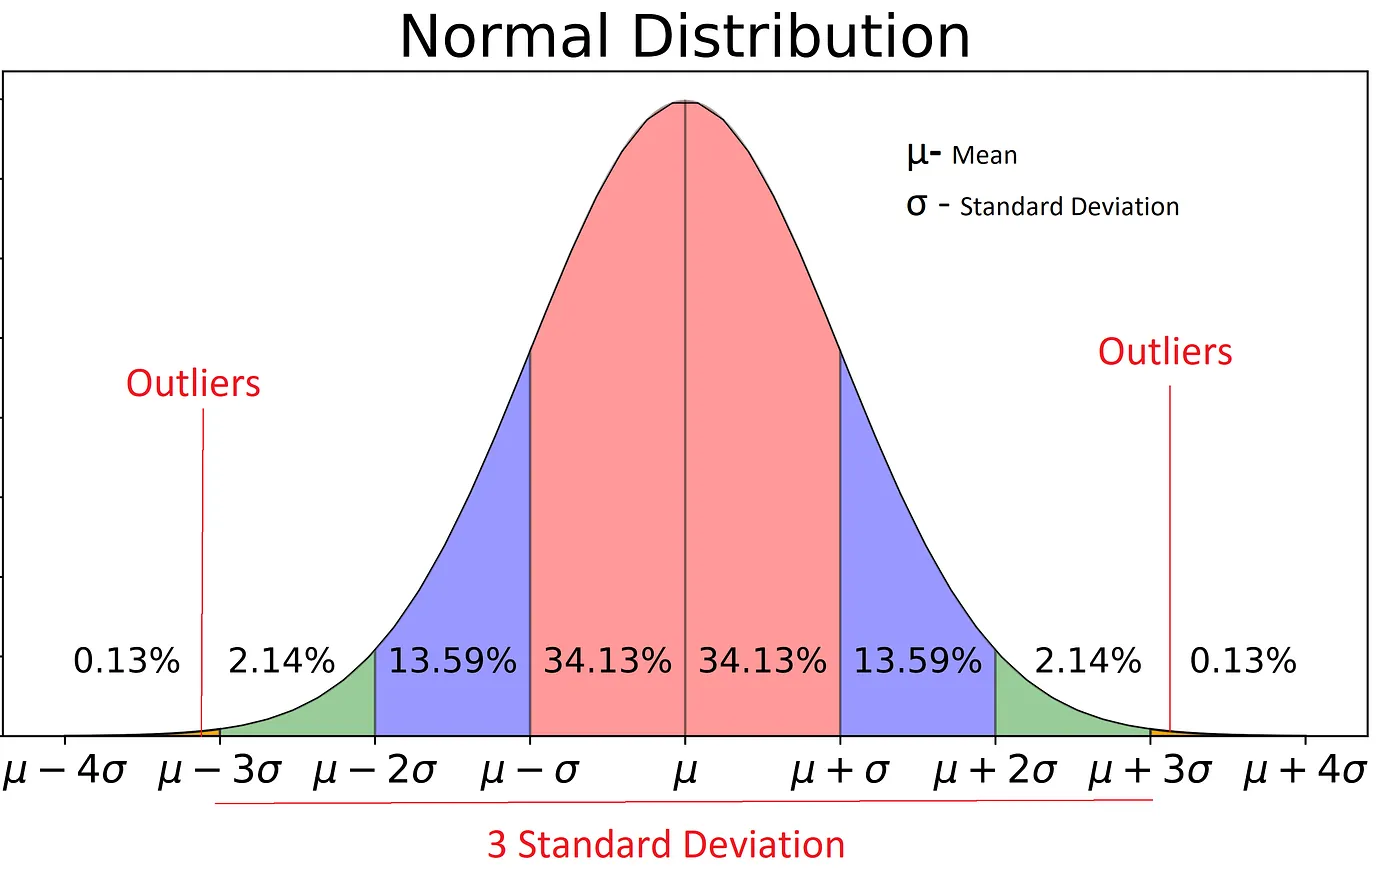

In [ ]:
# 1. Get the outliers
threshold = 3
# 1.1 get the training outliers
c2_training_outliers = c2_training_norm[(c2_training_norm<-threshold) | (c2_training_norm>threshold)]
c3_training_outliers = c3_training_norm[(c3_training_norm<-threshold) | (c3_training_norm>threshold)]
# 1.2 get the testing outliers
c2_testing_outliers = c2_testing_norm[(c2_testing_norm<-threshold) | (c2_testing_norm>threshold)]
c3_testing_outliers = c3_testing_norm[(c3_testing_norm<-threshold) | (c3_testing_norm>threshold)]

array([ 3.09428322,  3.82809472,  4.05142865, ..., -3.15906692,
       -3.25478146, -3.30795621])

<Figure size 1500x800 with 0 Axes>

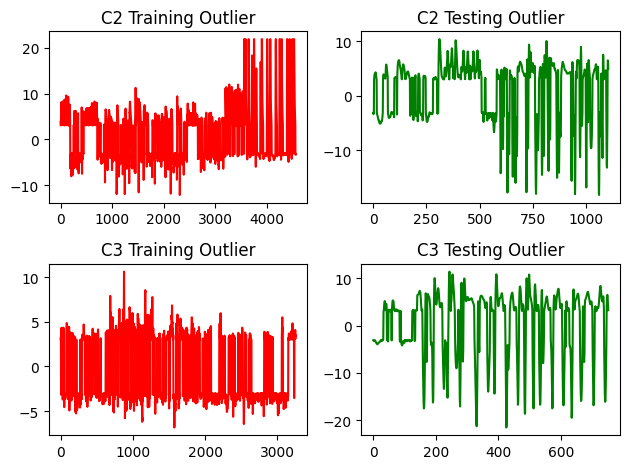

In [ ]:
# 1. Plot
plt.figure(figsize=(15, 8))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()
axes[0].plot(c2_training_outliers, 'r-', label="C2 Training Outlier")
axes[0].set_title("C2 Training Outlier")
axes[1].plot(c2_testing_outliers, 'g-', label="C2 Testing Outlier")
axes[1].set_title("C2 Testing Outlier")
axes[2].plot(c3_training_outliers ,'r-' , label="C3 Training Outlier")
axes[2].set_title("C3 Training Outlier")
axes[3].plot(c3_testing_outliers, 'g-' , label="C3 Testing Outlier")
axes[3].set_title("C3 Testing Outlier")
fig.tight_layout()

## Train a linear kernel SVM classifier using 80% of the dataset containing the outlier and evaluate its performance. Then remove the outlier, repeat the 80/20 training–testing process, and compare the results.

In [ ]:
# define the model
svm_model = SVC(C=1.0, kernel="linear", random_state=42)

In [ ]:
# find label for class 2 & 3
train_label2 = np.zeros(len(c2_training_norm))
train_label3 = np.ones(len(c3_training_norm))
test_label2 = np.zeros(len(c2_testing_norm))
test_label3 = np.ones(len(c3_testing_norm))

In [ ]:
# Prepare the trianing and testing dataset
final_train = np.vstack((c2_training_norm, c3_training_norm))
final_test = np.vstack((c2_testing_norm, c3_testing_norm))
final_train.shape, final_test.shape

((160, 4094), (40, 4094))

In [ ]:
# get the classes
final_y_train = np.hstack((train_label2, train_label3))
final_y_test = np.hstack((test_label2, test_label3))
final_y_train.shape, final_y_test.shape

((160,), (40,))

In [ ]:
# Fit the model on 80% of dataset with outlier
svm_model.fit(X=final_train, y=final_y_train.ravel())

SVC(kernel='linear', random_state=42)

In [ ]:
# Predict the model on the testing dataset
y_pred_1 = svm_model.predict(final_test)
y_pred_1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
       0., 1., 1., 0., 1., 0.])

In [ ]:
# Get the accuracy score
accuracy1 = accuracy_score(y_true=final_y_test.ravel(), y_pred=y_pred_1)
accuracy1

0.875

## Train a linear kernel SVM classifier using 80% of the dataset **without** the outlier and evaluate its performance, and compare the results.

 Now We have to superate the dataset from outliers
**Remove the outlier**


In [ ]:
threshold = 3
# 1. Cobine the two dataset c2 & c3
X = np.vstack(((c2-np.mean(c2))/np.std(c2), (c3-np.mean(c3))/np.std(c3)))
# 2. Create labels
y = np.hstack((np.zeros(len(c2)), np.ones(len(c3))))
# 3. Detect outlier
mask = np.all((X<threshold) & (X>-threshold), axis=1)
# 4. Remove outlier form X & y
X_clean = X[mask]
y_clean = y[mask]

Split the Training and Testing data 80% training & 20% testing

In [ ]:
# 1. split training data
X_train = X_clean[:80]
y_train = y_clean[:80]
#2. split testing data
X_test = X_clean[20:]
y_test = y_clean[20:]

In [ ]:
X_train.shape, y_train.shape

((60, 4095), (60,))

In [ ]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

In [ ]:
accuracy_score2 = accuracy_score(y_true=y_test, y_pred=y_pred)
accuracy_score2

1.0